# РГР
Выполняются расчеты по РГР 1. 1–2 этапы 
1  ЭТАП 1 Первичное описание выборки 
Что должен показать студент для каждого набора данных 
1.1 График эмпирической функции распределения 
n
 
F x 
1.2 Гистограмму с разным количеством интервалов. Должен уметь 
обосновать выбор числа интервалов 
1.3 Числовые значения  
a. Среднее 
x 
b. Смещенную дисперсию 2
S и S  
c. Несмещенную дисперсию 
отличия/совпадения 
d. Медиану 
e
2
 и 
 . Уметь объяснить причину 
m  
1.4 Короткое описание форму распределения: симметрия/асиммет
рия, наличие «хвостов», выбросов, нескольких мод 
2  ЭТАП 2 Предположение о виде закона распределения 
Что должен показать студент для каждого набора данных 
2.1 Используя ранее полученную информацию указать соответствие 
между наборами данных 1 3
X X и законами распределения 
N ,U ,Exp
 
,
a b
,

 
,
c
2.2 По каждому набору указать существенные признаки, которые поз
волили сделать вывод о виде закона



In [1]:
# (Необязательно) Colab: загрузка файла variant_*.csv
# from google.colab import files
# files.upload()


Объём выборки: n = 100

Первые пять значений вариационного ряда: 31.9 32.1 32.8 34.9 35.1 
Последние пять значений вариационного ряда: 31.9 32.1 32.8 34.9 35.1 

Выборочные оценки:
  Среднее:      x̄ = 54.26
  Дисперсия:    s² = 128.59
  Ст. откл.:    s = 11.34
  Медиана:      x̃ = 54.60
  Размах:       [31.9, 82.0]

Правило Скотта:
  Ширина интервала: h = 8.55
  Число интервалов: k = 6



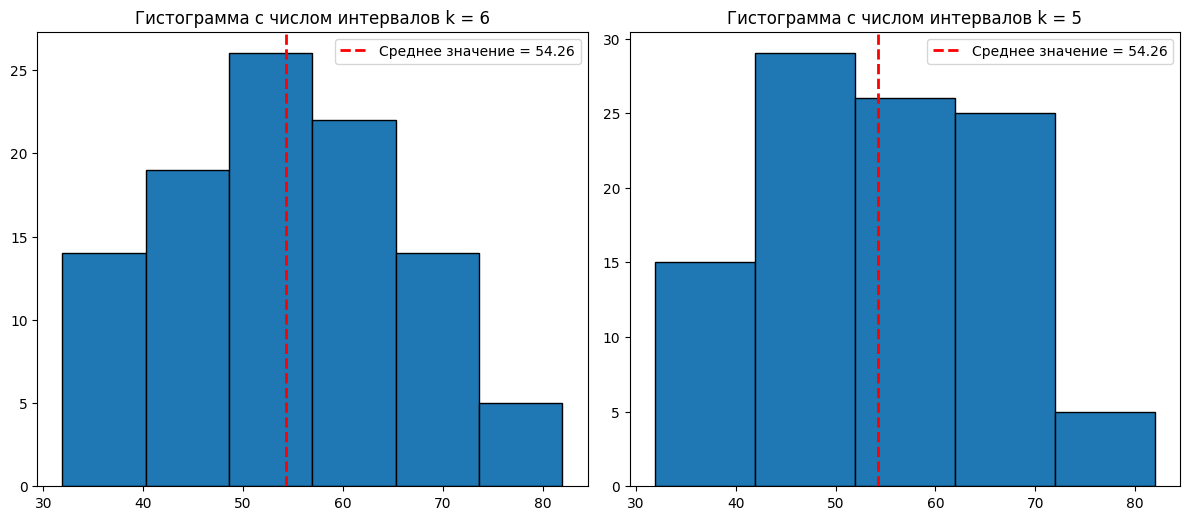

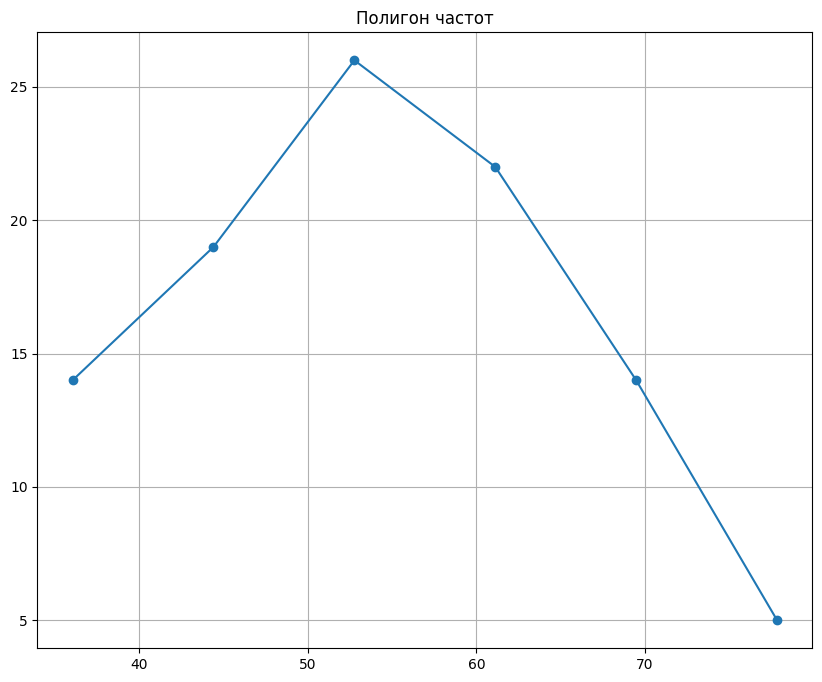

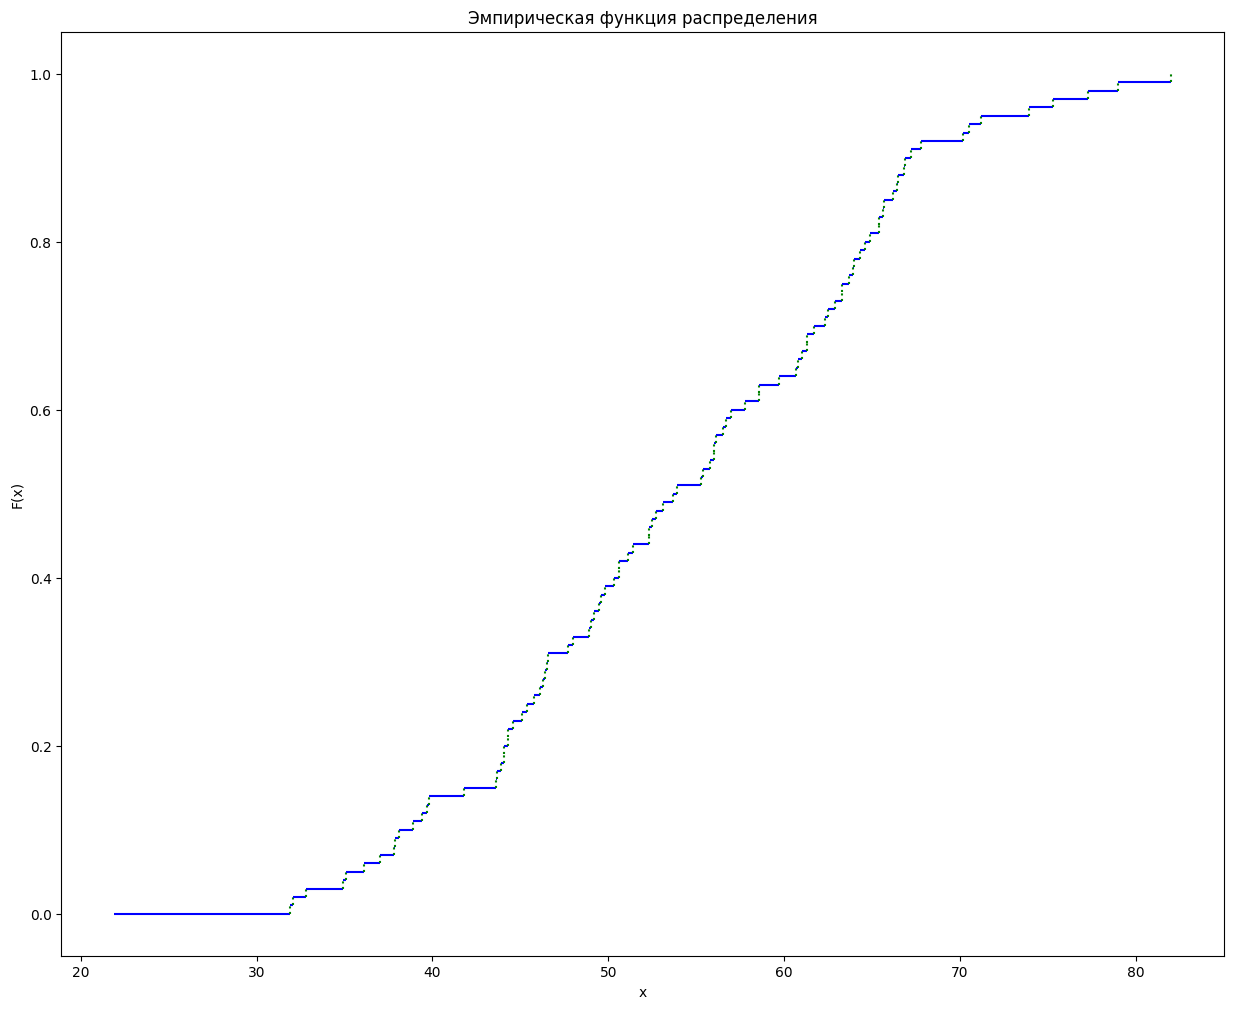

Сравнение с истинными параметрами:
  Истинное μ = 60, выборочное x̄ = 54.26
  Истинное σ² = 144, выборочное s² = 128.59

Вопрос: Почему выборочные оценки отличаются от истинных параметров?


In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# ЗАДАНИЕ: Первичная обработка выборки
# -------------------------------------------------
# ШАГ 0: Загрузите свою выборку (замените номер файла на ваш вариант)
data = np.loadtxt('variant_2.csv', delimiter=',')
n = len(data)
print(f"Объём выборки: n = {len(data)}")
print()

# -------------------------------------------------
# ШАГ 1: Вариационный ряд
# -------------------------------------------------
# ДОПОЛНИТЕ КОД:
sorted_data = sorted(data)

# Выведите первые 5 и последние 5 значений вариационного ряда
print("Первые пять значений вариационного ряда: ", end="")
for i in range(5):
    print(sorted_data[i], end=" ")
print()

print("Последние пять значений вариационного ряда: ", end="")
for i in range(5):
    print(sorted_data[i], end=" ")
print()
print()

# -------------------------------------------------
# ШАГ 2: Выборочные оценки
# -------------------------------------------------
# ДОПОЛНИТЕ КОД:
x_bar = sum(data) / n       # среднее
s2 = sum((x - x_bar)**2 for x in data) / n          # дисперсия (несмещённая!)
s = s2 ** 0.5           # стандартное отклонение
median = sorted_data[n // 2] if n % 2 == 1 else (sorted_data[n // 2] + sorted_data[n // 2 + 1]) / 2      # медиана
x_min = sorted_data[0]       # минимум
x_max = sorted_data[n - 1]       # максимум

print("Выборочные оценки:")
print(f"  Среднее:      x̄ = {x_bar:.2f}")
print(f"  Дисперсия:    s² = {s2:.2f}")
print(f"  Ст. откл.:    s = {s:.2f}")
print(f"  Медиана:      x̃ = {median:.2f}")
print(f"  Размах:       [{x_min:.1f}, {x_max:.1f}]")
print()

# -------------------------------------------------
# ШАГ 3: Правило Скотта и гистограмма
# -------------------------------------------------
# ДОПОЛНИТЕ КОД:

h = 3.5 * s * n**(-1/3)
k = math.ceil((x_max - x_min) / h)

print(f"Правило Скотта:")
print(f"  Ширина интервала: h = {h:.2f}")
print(f"  Число интервалов: k = {k}")
print()

# Постройте ДВЕ гистограммы рядом:
#  а) с числом интервалов по Скотту
#  б) с фиксированным числом интервалов = 5
# Добавьте на каждую вертикальную линию со средним значением

plt.figure(figsize=(12, 10))

for i, bincount in enumerate([k, 5]):
    ax = plt.subplot(2, 2, i + 1)
    
    ax.hist(sorted_data, bins=bincount, edgecolor="black")
    ax.axvline(x_bar, color="red", linestyle="--", 
               linewidth=2, label=f"Среднее значение = {x_bar:.2f}")
    ax.legend()

    ax.set_title(f"Гистограмма с числом интервалов k = {bincount}", size=12)

plt.tight_layout()
plt.show()

# -------------------------------------------------
# ШАГ 4: Полигон частот
# -------------------------------------------------
# ДОПОЛНИТЕ КОД:
# Постройте полигон частот для интервального ряда
# (используйте те же интервалы, что и в гистограмме по Скотту)

counts, gaps = np.histogram(sorted_data, bins=k)

centers = (gaps[:-1] + gaps[1:]) / 2

plt.figure(figsize=(10, 8))

plt.plot(centers, counts, marker="o")
plt.title("Полигон частот")

plt.grid(True)
plt.show()

# -------------------------------------------------
# ШАГ 5: Эмпирическая функция распределения
# -------------------------------------------------
# ДОПОЛНИТЕ КОД:
# Постройте график ЭФР с пунктирными вертикалями в точках скачков
# и точками на горизонтальных участках

probability = np.arange(1, n + 1) / n
probability = np.concatenate(([0], probability, [1]))

extended_data = np.concatenate(([sorted_data[0] - 10] , sorted_data, [sorted_data[-1] + 10]))

plt.figure(figsize=(15, 12))

# plt.step(
#     np.concatenate(([sorted_data[0] - 10] , sorted_data, [sorted_data[-1] + 10])), 
#     np.concatenate(([0], probability, [1])), 
#     where="post")

for i in range(n):
    plt.hlines(probability[i], extended_data[i], extended_data[i + 1],
               color="blue")
    plt.vlines(extended_data[i + 1], probability[i], probability[i + 1], 
               linestyles=":", color="green")

plt.title("Эмпирическая функция распределения")
plt.xlabel("x")
plt.ylabel("F(x)")

plt.show()

# -------------------------------------------------
# ШАГ 6: Сравнение с истинными параметрами
# -------------------------------------------------
# Истинные параметры вашего варианта:
mu_true = 60
sigma2_true = 144

print("Сравнение с истинными параметрами:")
print(f"  Истинное μ = {mu_true}, выборочное x̄ = {x_bar:.2f}")
print(f"  Истинное σ² = {sigma2_true}, выборочное s² = {s2:.2f}")
print()
print("Вопрос: Почему выборочные оценки отличаются от истинных параметров?")
